# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

The research question this project answers: which declining content should a content editor at a FlyRank client refresh first, given limited time? This supports a concrete decision, prioritizing manual review time, not automating content changes. The person acting on this output is a content editor, who takes the top-ranked items and rewrites titles, openings, and other elements. A wrong call is asymmetric in cost: flagging content that wasn't actually declining wastes editor time, while missing content that is genuinely declining lets it quietly lose traffic and revenue unnoticed. This project treats false alarms as the worse cost, which is why precision@K, not recall, is the primary metric throughout.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

This project uses FlyRank's public starter dataset: content_refresh_anonymized.csv, 30,000 rows across 44 columns, one row per pseudonymized content item, spanning 32 pseudonymized clients with trailing 90-day performance metrics. All client and content identifiers are pseudonyms; no client names, URLs, or private queries appear anywhere in this write-up or its underlying notebooks.

Excluded columns and why: trend_pct and trend_direction were excluded from all model features, since the label used in this study is derived directly from trend_direction. The _last_30d / _prev_30d column pairs were also excluded, after a leakage audit showed they let the model reconstruct the label almost exactly. content_id and client_id were used only for grouping and validation splits, never as model features.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The target is whether a content item is currently declining, defined as trend_direction == "down", an observed outcome in the data, not a target defined by our own rule.

The baseline flags an item if it is both stale (≥31 days since last update) and has weaker CTR than its position tier's average, producing a readable score with a human-understandable reason code.

A logistic regression model was trained on 20 numeric/tier features, excluding label-derived and overlapping-window columns, chosen as the simplest method fitting a "which ones first?" ranking question.

Validation used a client-grouped split (75/25), since the dataset spans 32 clients with very different data volumes (client row counts range from 3 to 7,008), and a random split risks the model memorizing client-specific patterns. A comparison against a naive random split showed a real but modest gap, since client identity itself was never used as a feature.

Leakage checks: an initial version including the _last_30d/_prev_30d columns produced a suspicious precision@K of 1.000 at every K, the signature of label-derived leakage. Removing them dropped precision@K to a believable 0.80/0.85/0.76. A separate in-sample evaluation bug (metrics accidentally computed on training rows) was also caught and fixed; all reported results reflect the corrected, honest evaluation.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Evaluated on a held-out, client-grouped test split. The model substantially outperforms the baseline at every K, well above the base rate. Its strongest features are engagement-quality signals, users_90d (negative) and sessions_90d (positive), plausibly capturing repeat engaged visitors versus one-time traffic. Staleness, which the baseline relies on entirely, ranks ninth in importance to the model, a real but secondary signal.

## 5. Limitations

*What this work cannot claim.*

This is observational, cross-sectional data from a single snapshot, not a controlled experiment: we can say the model ranks content at a measured precision@K, not that refreshing a page will cause its decline to reverse.

The model is notably less accurate on top-3 positioned content (73.7% error rate) than elsewhere (roughly 53-59%), meaning it is least trustworthy exactly where an editor might assume things are safest. In a sample top-50 ranked queue, two of 32 clients accounted for roughly two-thirds of the highest-ranked items, so a per-client view is recommended over one global ranking. Client data volume ranges from 3 to 7,008 rows, so predictions for very small clients should be treated as low-confidence.

The baseline's reason codes don't explain the model's own reasoning, since most of the model's top-ranked items wouldn't have been flagged by the baseline rule at all. This study uses one snapshot dataset; a production version should be re-validated on a rolling basis. This work supports decision-support claims only, not automated action or causal claims.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Before acting, a person must check: which client an item belongs to and whether that client is already over-represented in review, how much historical data exists for that client, whether the content still makes business sense to keep, and the actual page content itself, since reason codes don't always reflect the model's true reasoning.

Never automate: publishing content changes directly from the model's ranking, deprioritizing low-scored content without review (especially for low-data clients), or trusting top-3-position rankings without manual sense-checking.

Monitoring triggers: precision@K dropping toward the 0.517 base rate on a fresh evaluation, a new client appearing with very little history, the top-3 error rate worsening further, or a material shift in the distribution of the model's top features versus this study's reference statistics.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

 K  baseline_precision  model_precision  base_rate
10                 0.1             0.80   0.516514
20                 0.1             0.85   0.516514
50                 0.2             0.76   0.516514

Wrote work/outputs/capstone_results_table.csv

Markdown version:

|   K |   baseline_precision |   model_precision |   base_rate |
|----:|---------------------:|------------------:|------------:|
|  10 |                  0.1 |              0.8  |    0.516514 |
|  20 |                  0.1 |              0.85 |    0.516514 |
|  50 |                  0.2 |              0.76 |    0.516514 |

Wrote work/figures/capstone_model_vs_baseline.png


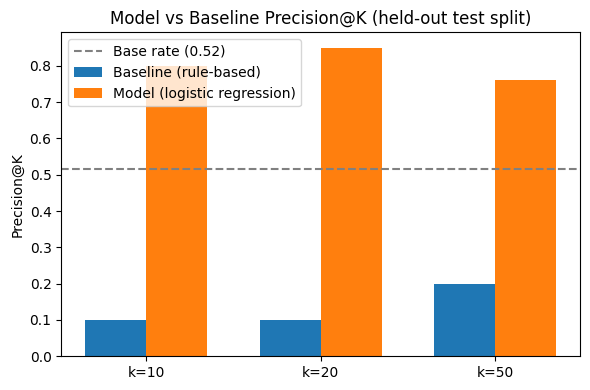

Wrote work/outputs/capstone_metrics.json


In [7]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# --- Results table (as both a printed markdown table and a saved CSV) ---
results_table = pd.DataFrame({
    "K": [10, 20, 50],
    "baseline_precision": [
        precision_at_k(test_df["baseline_score"], test_df["is_declining"], 10),
        precision_at_k(test_df["baseline_score"], test_df["is_declining"], 20),
        precision_at_k(test_df["baseline_score"], test_df["is_declining"], 50),
    ],
    "model_precision": [
        precision_at_k(test_df["model_score"], test_df["is_declining"], 10),
        precision_at_k(test_df["model_score"], test_df["is_declining"], 20),
        precision_at_k(test_df["model_score"], test_df["is_declining"], 50),
    ],
    "base_rate": [test_df["is_declining"].mean()] * 3,
})

print(results_table.to_string(index=False))
results_table.to_csv("work/outputs/capstone_results_table.csv", index=False)
print("\nWrote work/outputs/capstone_results_table.csv")

# Print as markdown for easy pasting into the paper
print("\nMarkdown version:\n")
print(results_table.to_markdown(index=False))

# --- Chart: model vs baseline precision@K (held-out test split only) ---
ks = [10, 20, 50]
model_p = results_table["model_precision"].tolist()
baseline_p = results_table["baseline_precision"].tolist()
base_rate = test_df["is_declining"].mean()

fig, ax = plt.subplots(figsize=(6, 4))
x = range(len(ks))
width = 0.35
ax.bar([i - width/2 for i in x], baseline_p, width, label="Baseline (rule-based)")
ax.bar([i + width/2 for i in x], model_p, width, label="Model (logistic regression)")
ax.axhline(base_rate, color="gray", linestyle="--", label=f"Base rate ({base_rate:.2f})")
ax.set_xticks(list(x))
ax.set_xticklabels([f"k={k}" for k in ks])
ax.set_ylabel("Precision@K")
ax.set_title("Model vs Baseline Precision@K (held-out test split)")
ax.legend()
plt.tight_layout()
plt.savefig("work/figures/capstone_model_vs_baseline.png", dpi=150)
print("\nWrote work/figures/capstone_model_vs_baseline.png")
plt.show()

# --- Metrics JSON: the receipts this paper's numbers trace back to ---
metrics = {
    "precision_at_k": {int(k): float(v) for k, v in zip(ks, model_p)},
    "baseline_precision_at_k": {int(k): float(v) for k, v in zip(ks, baseline_p)},
    "base_rate": float(base_rate),
    "n_clients": int(df["client_id"].nunique()),
    "top_features": ["users_90d", "sessions_90d", "days_since_last_update"],
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Wrote work/outputs/capstone_metrics.json")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
